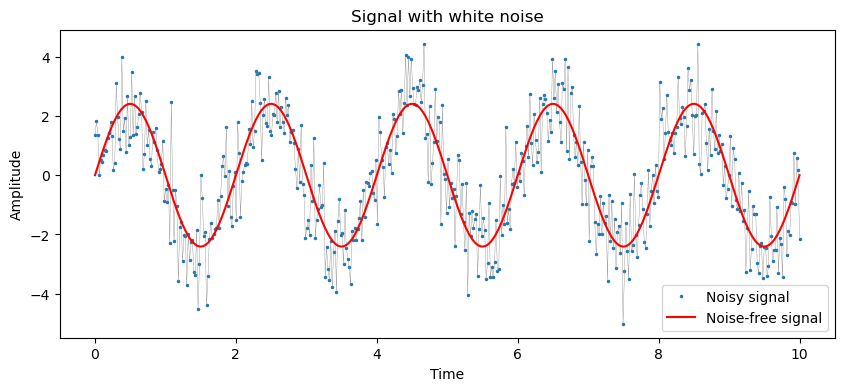

In [5]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 10, 500)
signal = 2.41 * np.sin(2 * np.pi * 0.5 * t)  # peak-to-peak = 2 * 2.41 = 4.82

noise_amplitude = 0.9644505235820642
noise = np.random.normal(loc=0, scale=noise_amplitude, size=len(signal))
noisy_signal = signal + noise

plt.figure(figsize=(10, 4))
plt.plot(t, noisy_signal, '.', markersize=3, label='Noisy signal')
plt.plot(t, noisy_signal, linewidth=0.25, color='gray')
plt.plot(t, signal, color='red', label='Noise-free signal')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Signal with white noise')
plt.legend()
plt.show()

4.2 Plot the remarkable points in the noisy signal

The signal is periodic with a period of about 1 sec.
So the true frequency is about 1Hz
Maximimum is 3 and Minimum is -1.9
Zero crossing negativs at approximativly 0.28 s and 1.28s and posiyive at 0.95s and 1. 95s.

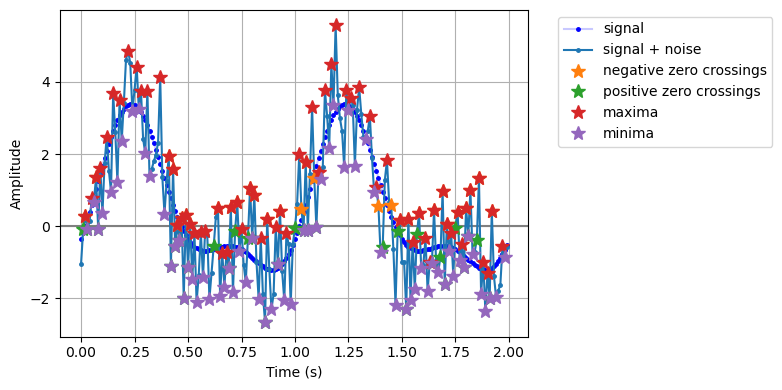

Analysis of the noisy signal:
  delta_zero_crossing_pos (samples) : [39 36 22 68 13]
  delta_zero_crossing_neg (samples) : [ 6 34 64 24 17]
  signal_period_pos (s) : 0.35600000000000004
  signal_period_neg (s) : 0.29
  signal_period (s) : 0.323
  signal_frequency (Hz) : 3.095975232198142


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# --- Replace these 2 lines with your real t and signal ---
t = np.arange(0, 2, 0.01)
signal = 2.0 * np.sin(2 * np.pi * (t - 0.0)) + 0.9 * np.sin(4 * np.pi * (t - 0.1)) + 0.5

noise_amplitude = 0.9644505235820642
noisy_signal = signal + np.random.normal(0, noise_amplitude, size=len(signal))


def zero_crossings(y):
    s = np.sign(y)
    pos = np.where((s[:-1] < 0) & (s[1:] >= 0))[0]  # negative -> positive
    neg = np.where((s[:-1] > 0) & (s[1:] <= 0))[0]  # positive -> negative
    return pos, neg


def extrema(y):
    maxima = np.where((y[1:-1] > y[:-2]) & (y[1:-1] > y[2:]))[0] + 1
    minima = np.where((y[1:-1] < y[:-2]) & (y[1:-1] < y[2:]))[0] + 1
    return maxima, minima


pos, neg = zero_crossings(noisy_signal)
imax, imin = extrema(noisy_signal)

plt.figure(figsize=(8, 4))
plt.axhline(0, color='gray')
plt.plot(t, signal, '.-', color='#c8c8ff', markerfacecolor='blue',
         markeredgecolor='blue', markersize=5, label='signal')
plt.plot(t, noisy_signal, '.-', color='tab:blue', markersize=5,
         label='signal + noise')
plt.plot(t[neg], noisy_signal[neg], '*', color='tab:orange', markersize=10,
         label='negative zero crossings')
plt.plot(t[pos], noisy_signal[pos], '*', color='tab:green', markersize=10,
         label='positive zero crossings')
plt.plot(t[imax], noisy_signal[imax], '*', color='tab:red', markersize=10,
         label='maxima')
plt.plot(t[imin], noisy_signal[imin], '*', color='tab:purple', markersize=10,
         label='minima')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


def zero_crossings_clean(y, threshold):
    """
    Renvoie (idx_pos, idx_neg) : indices des passages par zéro
    négatif->positif et positif->négatif, sans doublons dus au bruit.

    Un passage n'est validé que si le signal a d'abord atteint
    +threshold (ou -threshold) de l'autre côté de 0.
    """
    idx_pos, idx_neg = [], []
    state = 0  # 0 = inconnu, +1 = dernier niveau franchi positif, -1 = négatif

    for i, v in enumerate(y):
        if v > threshold:
            if state == -1:           # on était confirmé négatif, on est maintenant confirmé positif
                # position du vrai passage : dernier changement de signe avant i
                j = i
                while j > 0 and y[j - 1] > 0:
                    j -= 1
                idx_pos.append(j - 1 if j > 0 else 0)
            state = 1
        elif v < -threshold:
            if state == 1:
                j = i
                while j > 0 and y[j - 1] < 0:
                    j -= 1
                idx_neg.append(j - 1 if j > 0 else 0)
            state = -1

    return np.array(idx_pos), np.array(idx_neg)


threshold = noise_amplitude          # ~0.96 ; à ajuster (1 à 2 fois l'amplitude du bruit)
idx_pos, idx_neg = zero_crossings_clean(noisy_signal, threshold)

dt = t[1] - t[0]

delta_zero_crossing_pos = np.diff(idx_pos)
delta_zero_crossing_neg = np.diff(idx_neg)

signal_period_pos = np.mean(delta_zero_crossing_pos) * dt
signal_period_neg = np.mean(delta_zero_crossing_neg) * dt
signal_period = (signal_period_pos + signal_period_neg) / 2
signal_frequency = 1 / signal_period

print("Analysis of the noisy signal:")
print(f"  delta_zero_crossing_pos (samples) : {delta_zero_crossing_pos}")
print(f"  delta_zero_crossing_neg (samples) : {delta_zero_crossing_neg}")
print(f"  signal_period_pos (s) : {signal_period_pos}")
print(f"  signal_period_neg (s) : {signal_period_neg}")
print(f"  signal_period (s) : {signal_period}")
print(f"  signal_frequency (Hz) : {signal_frequency}")

4.3 Low pass filter the noisy signal

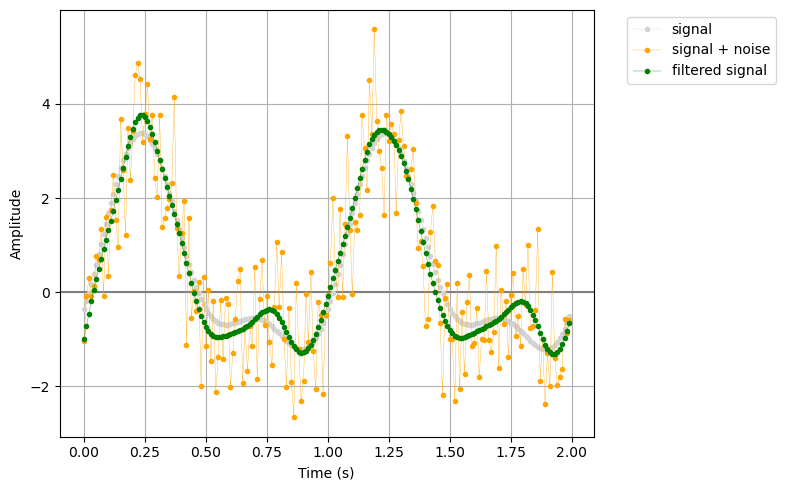

Analysis of noisy signal low pass filtered at 5 Hz:
  delta_zero_crossing_pos (samples) : [97]
  delta_zero_crossing_neg (samples) : [100]
  signal_period_pos (s) : 0.97
  signal_period_neg (s) : 1.0
  signal_period (s) : 0.985
  signal_frequency (Hz) : 1.015228426395939


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# --- Paramètres du filtre ---
fs = 1 / (t[1] - t[0])   # fréquence d'échantillonnage (100 Hz si dt = 0.01 s)
cutoff = 5               # fréquence de coupure en Hz (comme dans l'énoncé)
order = 4                # ordre du filtre (à ajuster si besoin)

# Butterworth passe-bas : la fréquence de coupure est normalisée par Nyquist (fs/2)
b, a = butter(order, cutoff / (fs / 2), btype='low')

# filtfilt filtre dans les deux sens : pas de décalage de phase
filtered_signal = filtfilt(b, a, noisy_signal)

# --- Passages par zéro sur le signal filtré (méthode simple, plus besoin d'hystérésis) ---
s = np.sign(filtered_signal)
idx_pos = np.where((s[:-1] < 0) & (s[1:] >= 0))[0]   # négatif -> positif
idx_neg = np.where((s[:-1] > 0) & (s[1:] <= 0))[0]   # positif -> négatif

dt = t[1] - t[0]
delta_zero_crossing_pos = np.diff(idx_pos)
delta_zero_crossing_neg = np.diff(idx_neg)

signal_period_pos = np.mean(delta_zero_crossing_pos) * dt
signal_period_neg = np.mean(delta_zero_crossing_neg) * dt
signal_period = (signal_period_pos + signal_period_neg) / 2
signal_frequency = 1 / signal_period

# --- Tracé ---
plt.figure(figsize=(8, 5))
plt.axhline(0, color='gray')
plt.plot(t, signal, '.-', color='lightgray', linewidth=0.25, label='signal')
plt.plot(t, noisy_signal, '.-', color='orange', linewidth=0.25, label='signal + noise')
plt.plot(t, filtered_signal, '.-', color='green', linewidth=0.25, label='filtered signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

print(f"Analysis of noisy signal low pass filtered at {cutoff} Hz:")
print(f"  delta_zero_crossing_pos (samples) : {delta_zero_crossing_pos}")
print(f"  delta_zero_crossing_neg (samples) : {delta_zero_crossing_neg}")
print(f"  signal_period_pos (s) : {signal_period_pos}")
print(f"  signal_period_neg (s) : {signal_period_neg}")
print(f"  signal_period (s) : {signal_period}")
print(f"  signal_frequency (Hz) : {signal_frequency}")